In [1]:
#pip install seaborn



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
seed = 42


In [2]:
jan = pd.read_csv("janeiro.csv")
# feb = pd.read_csv("fevereiro.csv")
# mar = pd.read_csv("marco.csv")
# apr = pd.read_csv("abil.csv")
# may = pd.read_csv("maio.csv")
# jun = pd.read_csv("junho.csv")
# months = [jan, feb, mar, apr, may, jun]


/tmp/ipykernel_60942/1320863208.py:1: DtypeWarning: Columns (0: Valor, 1: Classe) have mixed types. Specify dtype option on import or set low_memory=False.
  jan = pd.read_csv("janeiro.csv")


In [9]:
# for i in months:
#     print(i.shape)
print(jan.shape)
jan.head()

(5400002, 18)


,Id_Eventos_Telemetria,Data_Evento,Inicio_Turno,Fim_Turno,Dia,Localidade,TAG,Tag_Frota,Tipo,Nome_Operador_Anon,Matricula_Operador_Hash,Id_Alarme,Alarme,Id_Criticidade,Criticidade,Valor,Classe,Is_Dont_Go
0,9372078,2025-01-01 00:00:14.553000,2024-12-31 18:00:00.000,2025-01-01 06:00:00.000,1,Itabira,CA5926,793-D 5S,Caminhao,OP_261,H_7d2a33163e23,335609934,Rx Channel A Not Receiving Messages,3,Informacional,0,NaN,0
1,9372079,2025-01-01 00:00:14.553000,2024-12-31 18:00:00.000,2025-01-01 06:00:00.000,1,Itabira,CA5926,793-D 5S,Caminhao,OP_261,H_7d2a33163e23,335609935,Rx Channel B Not Receiving Messages,3,Informacional,0,NaN,0
2,9372097,2025-01-01 00:02:20.280000,2024-12-31 18:00:00.000,2025-01-01 06:00:00.000,1,Itabira,CA5926,793-D 5S,Caminhao,OP_261,H_7d2a33163e23,84626976,Dipper,3,Informacional,"43,7999992370605",NaN,0
3,9372111,2025-01-01 00:02:59.077000,2024-12-31 18:00:00.000,2025-01-01 06:00:00.000,1,Itabira,CA5926,793-D 5S,Caminhao,OP_261,H_7d2a33163e23,84626976,Dipper,3,Informacional,"74,7000045776367",NaN,0
4,9372120,2025-01-01 00:03:37.963000,2024-12-31 18:00:00.000,2025-01-01 06:00:00.000,1,Itabira,CA5926,793-D 5S,Caminhao,OP_261,H_7d2a33163e23,84626976,Dipper,3,Informacional,"103,800003051758",NaN,0


In [3]:


def show_missig_values(dataset):
    rows = dataset.shape[0]
    missing_counts = dataset.isnull().sum().reset_index()
    missing_counts.columns = ["coluna", "valores_faltantes"]
    
    print("Número de valores faltando.")
    for col, val in dataset.isnull().sum().items():
        print(f"{col}: {val} -> {val/rows*100:.2f}%")
    
    plt.figure(figsize=(12,6))
    sns.barplot(data=missing_counts, 
                x="coluna", 
                y="valores_faltantes",
                hue="coluna",
                palette="viridis",
                legend=False,
                dodge=False)
    
    plt.xticks(rotation=45, ha='right')
    plt.title("Valores Faltando por Coluna", fontsize=16)
    plt.xlabel("Colunas")
    plt.ylabel("Número de valores faltantando")
    plt.tight_layout()
    plt.show()
#for i in months:
#    show_missig_values(i)

In [7]:
# Dropping the Classe column 
for month in range(len(months)):
    months[month] = months[month].drop(columns="Classe")

In [8]:
for i in months:
    print(i.shape)

(5400002, 17)
(5709935, 17)
(5688538, 17)
(6475045, 17)
(6036291, 17)
(7854243, 17)


In [4]:
def show_distribution(dataset, cut_columns=[], max_categories=50000):
    """
    Exibe a distribuição de colunas relevantes, filtrando IDs, 
    colunas constantes e alta cardinalidade.
    """
    for col in dataset.columns:
        # 1. Filtro de colunas ignoradas manualmente
        if col in cut_columns:
            continue
            
        # 2. Filtro de Variância: Ignora se a coluna tiver apenas 1 valor único (ex: Localidade "Itabira" em tudo)
        unique_count = dataset[col].nunique()
        if unique_count <= 1:
            continue
            
        # 3. Filtro de IDs/Alta Cardinalidade: Se for ID ou Hash (muitos valores únicos em relação ao total)
        # Se mais de 90% dos dados forem únicos, provavelmente é um ID/Chave Primária
        if unique_count > len(dataset) * 0.9:
            continue

        plt.figure(figsize=(10, 5))
        
        # Lógica para colunas NUMÉRICAS
        if pd.api.types.is_numeric_dtype(dataset[col]):
            plt.title(f"Distribuição Numérica: '{col}'", fontsize=12)
            sns.histplot(dataset[col], color="skyblue", bins=30, stat="density", kde=True)
            plt.ylabel("Densidade")
            
        # Lógica para colunas CATEGÓRICAS
        else:
            # Se tiver categorias demais (ex: nomes de operadores), pegamos apenas as Top X
            if unique_count > max_categories:
                data_to_plot = dataset[col].value_counts().head(max_categories)
                plt.title(f"Top {max_categories} Categorias: '{col}'", fontsize=12)
            else:
                data_to_plot = dataset[col].value_counts()
                plt.title(f"Distribuição Categórica: '{col}'", fontsize=12)

            sns.barplot(x=data_to_plot.index, y=data_to_plot.values, palette="viridis", hue=data_to_plot.index, legend=False)
            plt.xticks(rotation=45, ha="right")
            plt.ylabel("Frequência")

        plt.xlabel(col)
        plt.tight_layout()
        plt.show()

In [5]:

def particoes(month: pandas.series, n_chunks: int) -> list:
    chunk_size = len(month) // n_chunks
    
    
    return [month.iloc[i * chunk_size : (i + 1) * chunk_size] for i in range(n_chunks)]
    



In [7]:
partes = particoes(jan, 180)

print(partes[0])


       Id_Eventos_Telemetria                 Data_Evento  \
0                    9372078  2025-01-01 00:00:14.553000   
1                    9372079  2025-01-01 00:00:14.553000   
2                    9372097  2025-01-01 00:02:20.280000   
3                    9372111  2025-01-01 00:02:59.077000   
4                    9372120  2025-01-01 00:03:37.963000   
...                      ...                         ...   
29995               22923577  2025-01-31 00:13:53.397000   
29996               22923580  2025-01-31 00:14:03.000000   
29997               22923584  2025-01-31 00:14:04.550000   
29998               22923587  2025-01-31 00:14:09.477000   
29999               22923588  2025-01-31 00:14:11.217000   

                  Inicio_Turno                Fim_Turno  Dia Localidade  \
0      2024-12-31 18:00:00.000  2025-01-01 06:00:00.000    1    Itabira   
1      2024-12-31 18:00:00.000  2025-01-01 06:00:00.000    1    Itabira   
2      2024-12-31 18:00:00.000  2025-01-01 06:00:00.00

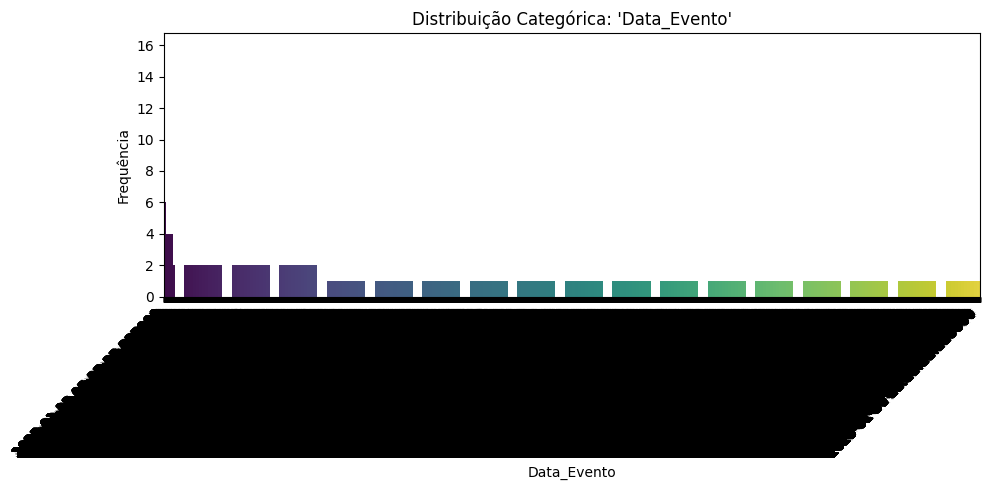

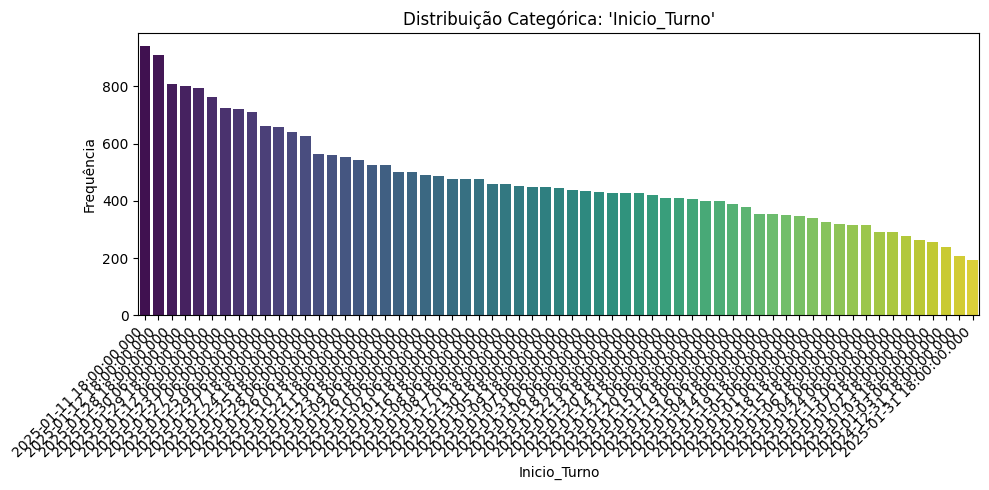

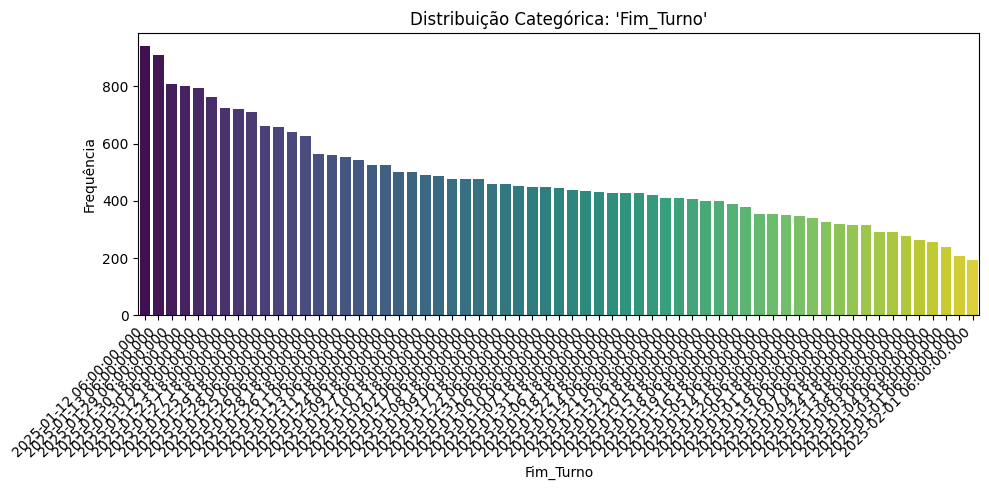

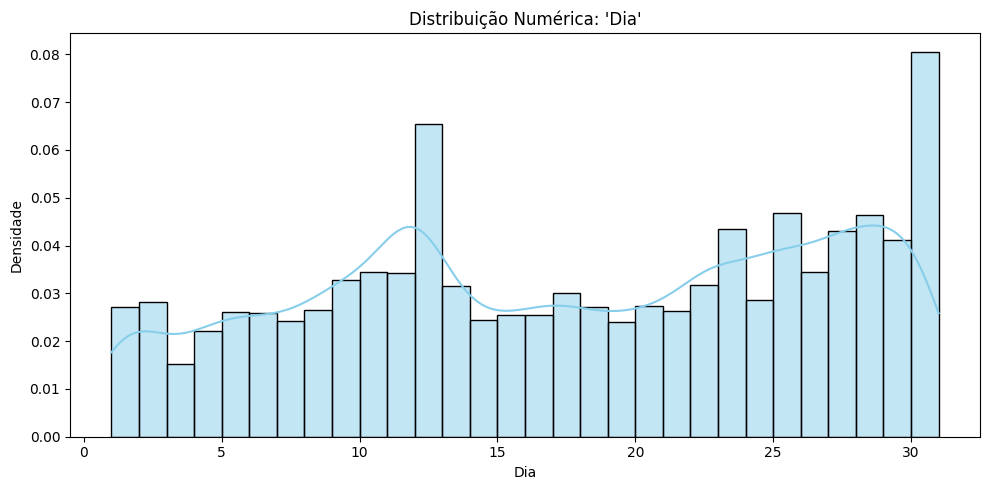

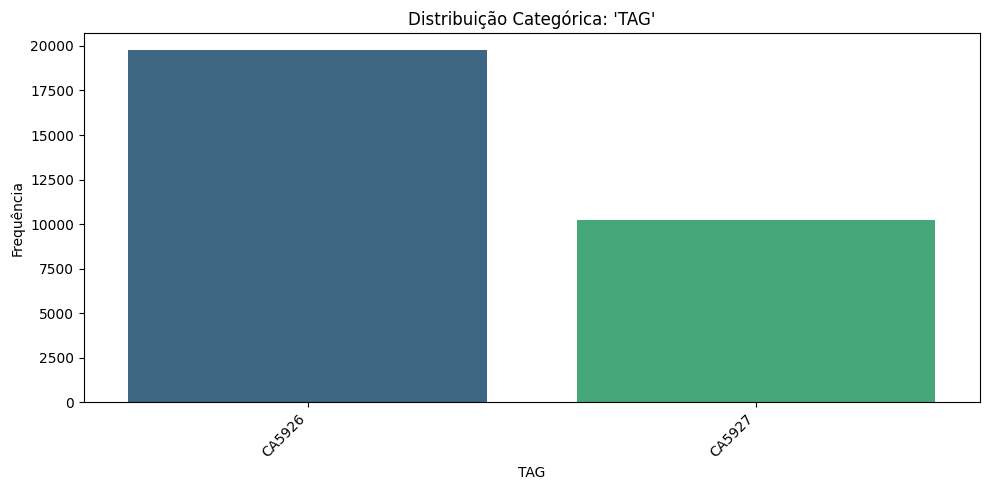

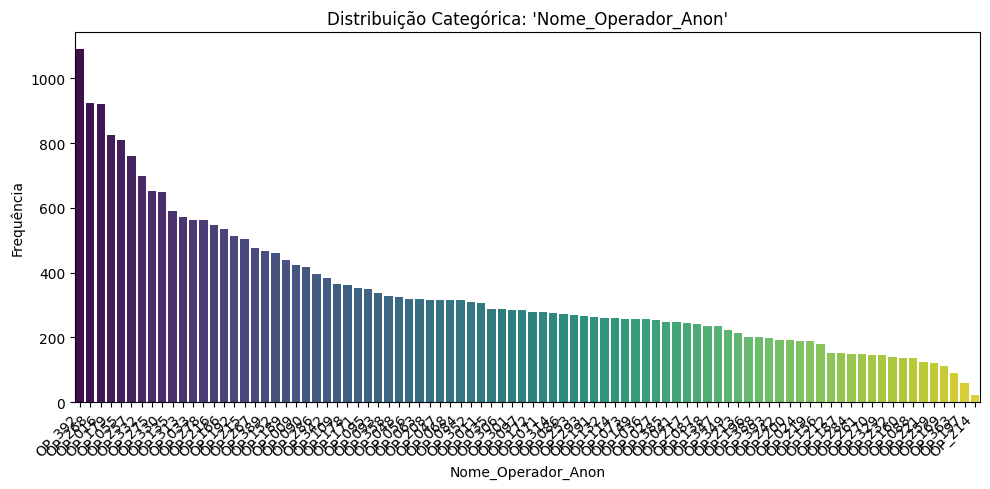

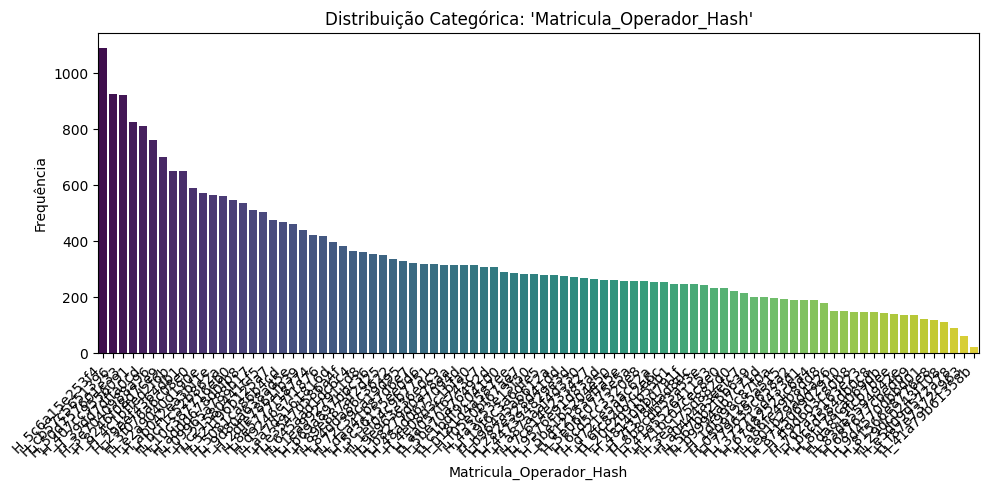

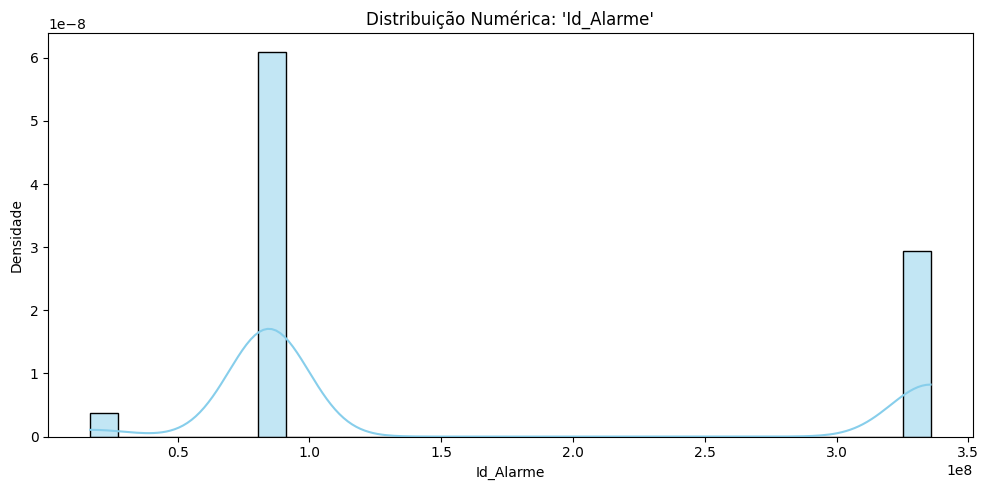

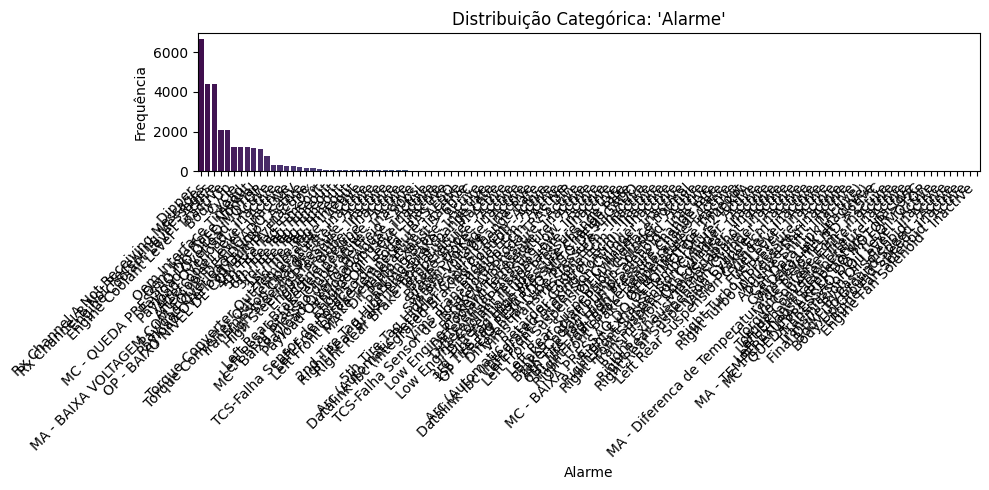

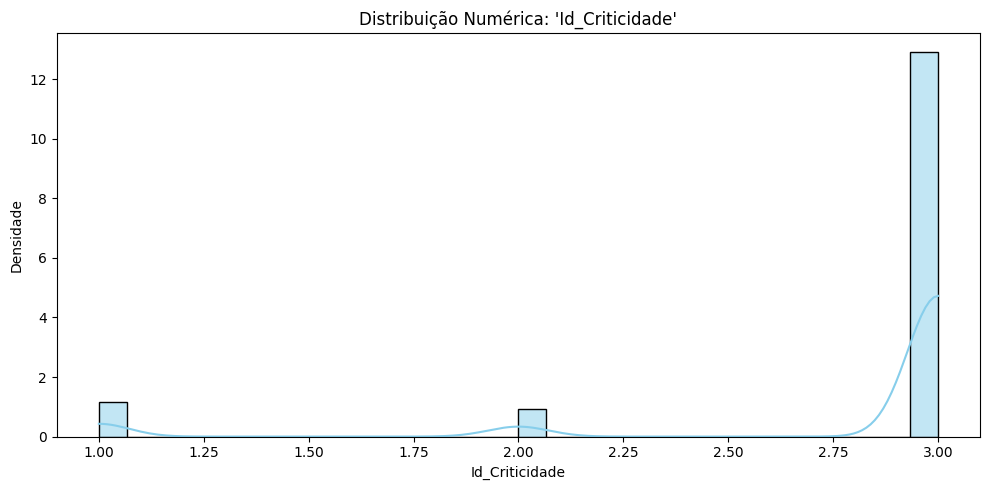

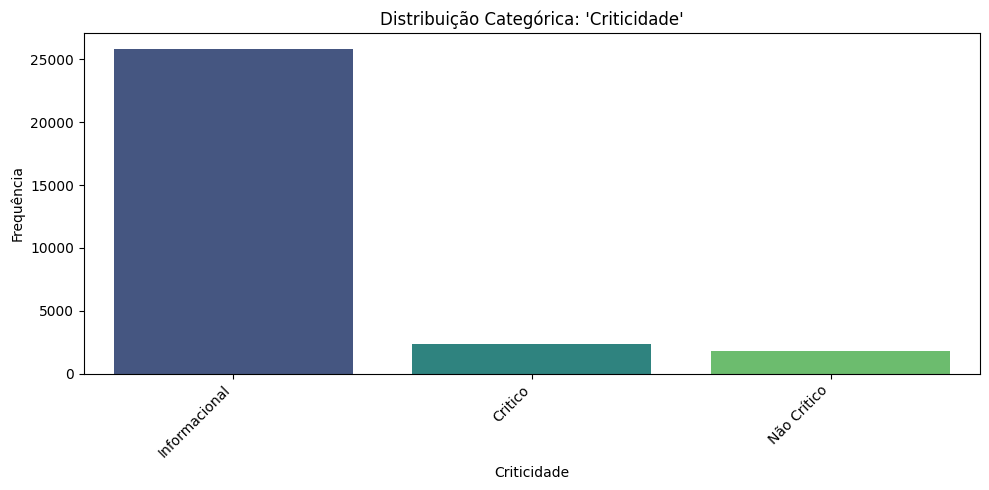

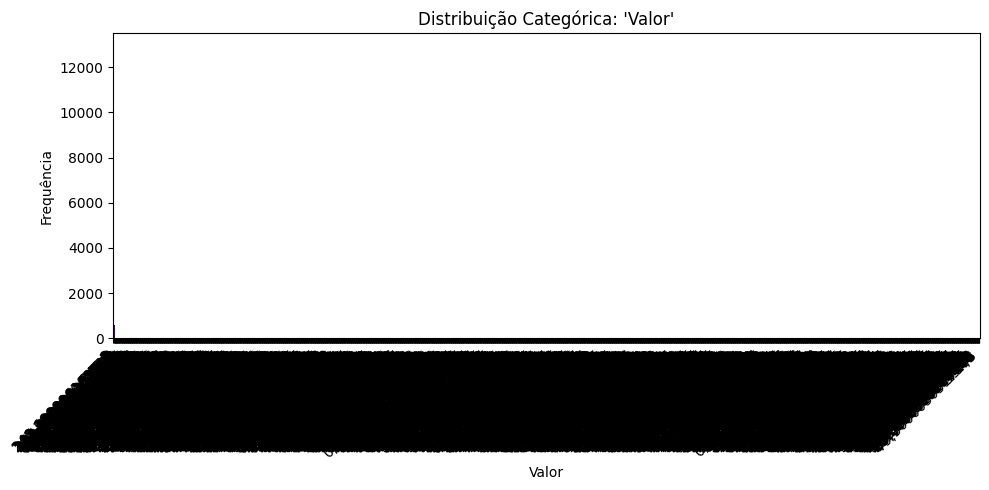

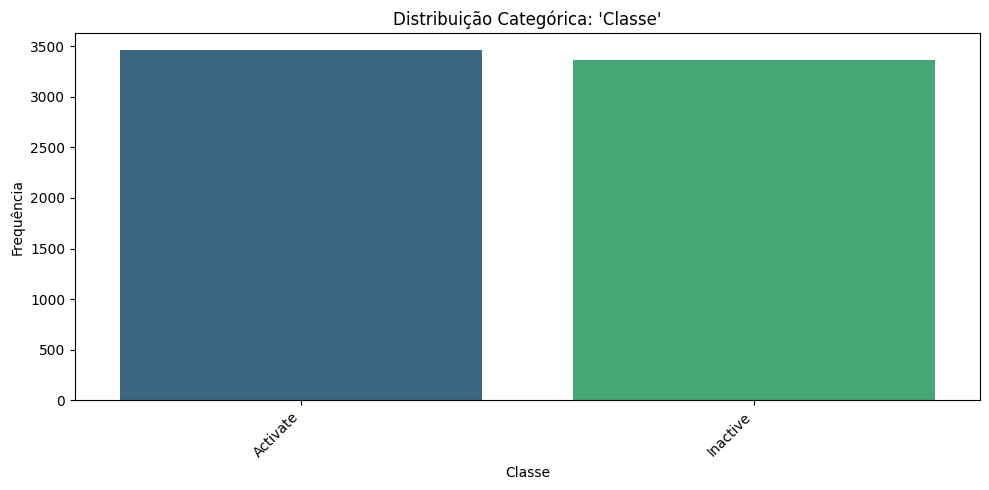

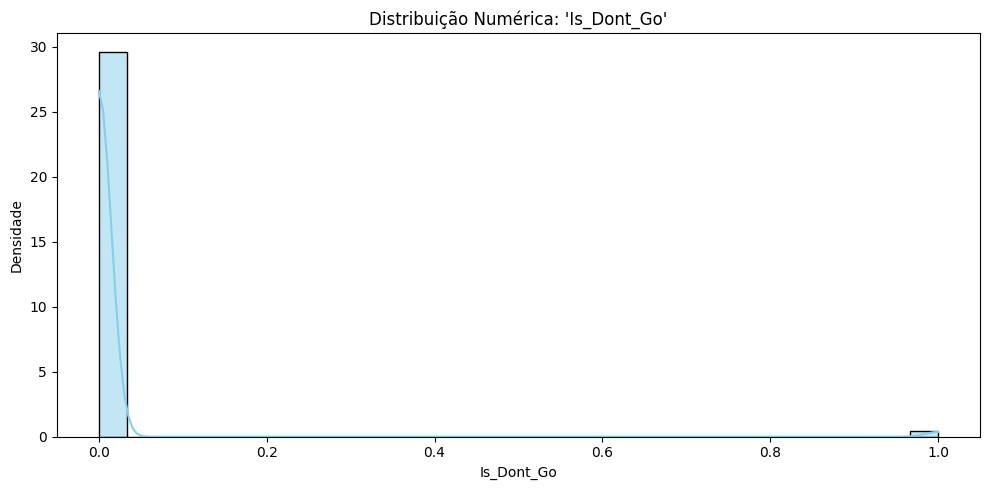

In [15]:
show_distribution(partes[0])

- Existem alarmes sem um valor correspondente, essas linhas podem ser descartadas?
- Features como inicio do turno e fim do turno podem ser agrupados em categorias como manha1, manha2, tarde1, tarde2?
- Classe tem 97% dos dados faltando, essa feature deve ser descartada?
- Ids devem ser considerados categóricos?
- O que eu devo fazer com alarme considerando que existem diversos tipos e é custoso visualizar todas as flags a olho nu?
- Quais features eu posso remover sem prejuízo?
- Posso agrupar diferentes tipos de "Alarme"? Se freio tem as possibilidades temperatura, pressão e auxiliar eu posso juntar tudo em freio ou devo separar em freio 1 para mais criticos e freios 2 para menos críticos?
- 

In [50]:
a = partes[0]["Alarme"].unique()
b = partes[0]["Criticidade"].unique()
a2 = partes[0]["Alarme"]
b2 = partes[0]["Criticidade"]
c = partes[0]["Is_Dont_Go"]
b

<StringArray>
['Informacional', 'Critico', 'Não Crítico']
Length: 3, dtype: str

In [38]:
for i in a:
    print(i)

Rx Channel A Not Receiving Messages
Rx Channel B Not Receiving Messages
Dipper 
Load
MC - QUEDA PRESSÃO DO ÓLEO MOTOR
Body Up
Cycle
Oem Interface Timeout
Oem Interface Normal
Payload Overload - Active
Payload Overload - Inactive
Left Rear Brake Temperature - Active
Right Rear Brake Temperature - Active
Right Rear Brake Temperature - Inactive
Left Rear Brake Temperature - Inactive
Payload Overload Dump - Active
Payload Overload Dump - Inactive
OP - BAIXO NÍVEL DE COMBUSTÍVEL <20%
4th Tire Tag Timeout
5th Tire Tag Timeout
6th Tire Tag Timeout
2nd Tire Tag Timeout
3rd Tire Tag Timeout
1st Tire Tag Timeout
Torque Converter Out Temperature - Active
Torque Converter Out Temperature - Inactive
Payload Overload Abuse - Active
Payload Overload Abuse - Inactive
High Steering Pressure - Active
High Steering Pressure - Inactive
4th Tire Tag High Pressure change rate
6th Tire Tag High Pressure Change Rate
3rd Tire Tag High Pressure change rate
Vims Brake Ecm - Active
OEM Interface normal
Left Front

In [53]:
total = 0
casos = 0
for i in zip(b2, c):
    if i[0] == "Critico":
        total = total + 1
    if i[0] == "Critico" and i[1] == 1:
        casos = casos + 1
casos/total

0.13458262350936967

13% dos casos críticos gera um dont go?
O que isso quer dizer, será que essa feature está correta ou eu estou interpretando errado?

In [61]:
def classificar_alarme_detalhado(nome_alarme):
    alarme = str(nome_alarme).upper()
    
    # ---------------------------------------------------------
    # 1. IDENTIFICAÇÃO DA SEVERIDADE (1 ou 2)
    # ---------------------------------------------------------
    # Palavras que indicam falha crítica, impacto direto ou parada
    criticos = ['MC -', 'MA -', 'ACTIVE', 'QUEDA', 'BAIXA PRESSÃO', 'FALHA', 'LOW PRESSURE', '>']
    
    # Palavras que indicam aviso, timeout, inatividade ou operação
    avisos = ['OP -', 'INACTIVE', 'TIMEOUT', 'NORMAL', 'CHANGE RATE', 'ABUSE', 'DUMP', 'LEVEL']
    
    # Define a severidade inicial
    severidade = "1" # Padrão é 1 (Aviso/Menos grave)
    if any(c in alarme for c in criticos) and not any(a in alarme for a in ['INACTIVE', 'NORMAL']):
        severidade = "2" # Se for crítico e NÃO estiver inativo/normal, vira 2

    # ---------------------------------------------------------
    # 2. IDENTIFICAÇÃO DO SISTEMA
    # ---------------------------------------------------------
    sistema = "Outros" # Categoria padrão se não achar nenhuma
    
    # Dicionário de sistemas e suas palavras-chave
    regras_sistemas = {
        "Motor": ['ENGINE', 'COOLANT', 'OIL', 'AFTERCOOLER', 'TURBO', 'EXHAUST', 'ARREF', 'COMBUSTÍVEL', 'PRELUBE', 'FAN'],
        "Freio": ['BRAKE', 'FREIO', 'IBC', 'ARC', 'RETARDO', 'PARKING'],
        "Transmissao": ['TRANSMISSION', 'TORQUE CONVERTER', 'SHIFT', 'DIFFERENTIAL', 'FINAL DRIVE', 'MARCHA'],
        "Suspensao_Lataria": ['SUSPENSION', 'STEERING', 'DIREÇÃO', 'CHASSIS'],
        "Pneu": ['TIRE', 'PNEU'],
        "Carga": ['PAYLOAD', 'DIPPER', 'LOAD', 'CYCLE', 'BODY UP'],
        "Eletronica": ['ECM', 'DATA LINK', 'VIMS', 'CHANNEL', 'OEM', 'VOLTAGEM', 'VOLTAGE', 'SENSOR']
    }
    
    # Busca qual sistema o alarme pertence
    for chave_sistema, palavras_chave in regras_sistemas.items():
        if any(palavra in alarme for palavra in palavras_chave):
            sistema = chave_sistema
            break # Achou o sistema, para de procurar
            
    # ---------------------------------------------------------
    # 3. RETORNA A COMBINAÇÃO (Ex: Freio2, Motor1, Pneu1)
    # ---------------------------------------------------------
    return f"{sistema}{severidade}"

In [62]:
novo = []
for alarme in partes[0]["Alarme"]:
    novo.append(classificar_alarme_detalhado(alarme))
novo
#classificar_alarme(partes[0]["Alarme"])

['Eletronica1',
 'Eletronica1',
 'Carga1',
 'Carga1',
 'Carga1',
 'Carga1',
 'Carga1',
 'Carga1',
 'Carga1',
 'Carga1',
 'Eletronica1',
 'Eletronica1',
 'Eletronica1',
 'Eletronica1',
 'Outros2',
 'Carga1',
 'Carga1',
 'Eletronica1',
 'Eletronica1',
 'Eletronica1',
 'Eletronica1',
 'Outros2',
 'Eletronica1',
 'Eletronica1',
 'Carga1',
 'Carga1',
 'Carga1',
 'Carga1',
 'Carga1',
 'Carga1',
 'Eletronica1',
 'Eletronica1',
 'Eletronica1',
 'Eletronica1',
 'Eletronica1',
 'Eletronica1',
 'Eletronica1',
 'Eletronica1',
 'Eletronica1',
 'Eletronica1',
 'Outros2',
 'Carga1',
 'Carga1',
 'Eletronica1',
 'Eletronica1',
 'Eletronica1',
 'Eletronica1',
 'Carga1',
 'Carga1',
 'Carga1',
 'Carga1',
 'Carga1',
 'Carga1',
 'Carga2',
 'Carga1',
 'Carga1',
 'Eletronica1',
 'Eletronica1',
 'Eletronica1',
 'Eletronica1',
 'Freio2',
 'Freio2',
 'Freio1',
 'Freio1',
 'Eletronica1',
 'Eletronica1',
 'Eletronica1',
 'Eletronica1',
 'Carga1',
 'Carga1',
 'Eletronica1',
 'Eletronica1',
 'Carga1',
 'Carga1',
 'C

Posso agrupar avisos operacionais e não criticos?